In [4]:
# Used Car Price Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# Load Dataset

df = pd.read_csv("../Dataset/Car Price.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (4340, 9)


,Brand,Model,Year,Selling_Price,KM_Driven,Fuel,Seller_Type,Transmission,Owner
0,Maruti,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [7]:
# Dataset Information
print("Column Names:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['Brand', 'Model', 'Year', 'Selling_Price', 'KM_Driven', 'Fuel', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Brand          4340 non-null   str  
 1   Model          4340 non-null   str  
 2   Year           4340 non-null   int64
 3   Selling_Price  4340 non-null   int64
 4   KM_Driven      4340 non-null   int64
 5   Fuel           4340 non-null   str  
 6   Seller_Type    4340 non-null   str  
 7   Transmission   4340 non-null   str  
 8   Owner          4340 non-null   str  
dtypes: int64(3), str(6)
memory usage: 575.6 KB

Missing Values:
Brand            0
Model            0
Year             0
Selling_Price    0
KM_Driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [8]:
# Dataset Information

print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['Brand', 'Model', 'Year', 'Selling_Price', 'KM_Driven', 'Fuel', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Brand          4340 non-null   str  
 1   Model          4340 non-null   str  
 2   Year           4340 non-null   int64
 3   Selling_Price  4340 non-null   int64
 4   KM_Driven      4340 non-null   int64
 5   Fuel           4340 non-null   str  
 6   Seller_Type    4340 non-null   str  
 7   Transmission   4340 non-null   str  
 8   Owner          4340 non-null   str  
dtypes: int64(3), str(6)
memory usage: 575.6 KB

Missing Values:
Brand            0
Model            0
Year             0
Selling_Price    0
KM_Driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [9]:
# Statistical Summary

display(df.describe())

,Year,Selling_Price,KM_Driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [10]:
# Check Duplicate Rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 763


In [11]:
# Missing Value Analysis

print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:
Brand            0
Model            0
Year             0
Selling_Price    0
KM_Driven        0
Fuel             0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total Missing Values: 0


In [13]:
#EDA

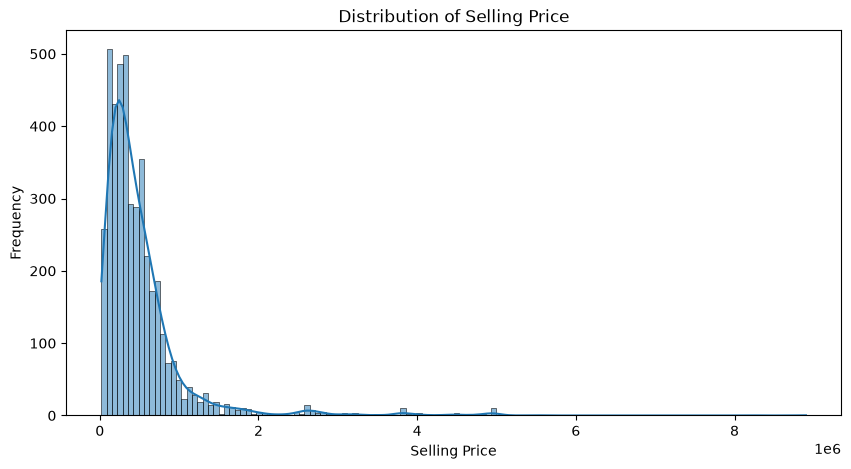

In [16]:
# Distribution of Selling Price

plt.figure(figsize=(10, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

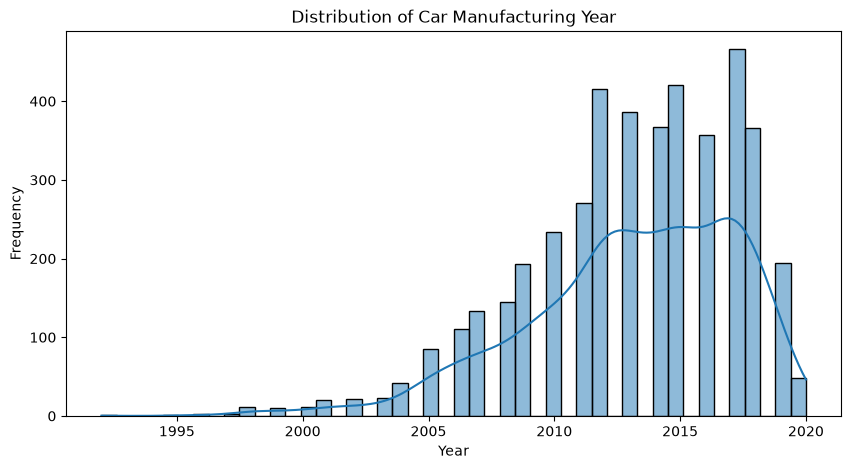

In [18]:
# Distribution of Car Year

plt.figure(figsize=(10, 5))

sns.histplot(df["Year"], kde=True)

plt.title("Distribution of Car Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Frequency")

plt.show()

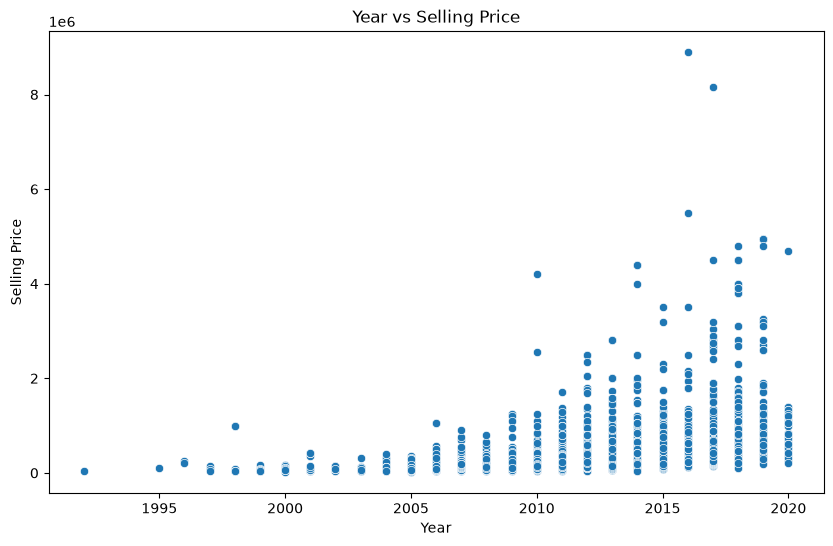

In [21]:
# Year vs Selling Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price"
)

plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")

plt.show()

In [23]:
# Separate Features and Target

X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

print("Feature Columns:")
print(X.columns.tolist())

print("\nTarget Column:")
print("Selling_Price")

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Columns:
['Brand', 'Model', 'Year', 'KM_Driven', 'Fuel', 'Seller_Type', 'Transmission', 'Owner']

Target Column:
Selling_Price

Features Shape: (4340, 8)
Target Shape: (4340,)


In [24]:
# Identify Numerical and Categorical Features

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Year', 'KM_Driven']

Categorical Features:
['Brand', 'Model', 'Fuel', 'Seller_Type', 'Transmission', 'Owner']


In [ ]:
# One-Hot Encoding of Categorical Features
#BECAUSE TO CONVERT CATEGORY FEATURES INTO NUMERICAL FORMAT FOR regression model

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

# Convert True/False values to 0/1
X_encoded = X_encoded.astype(int)

print("Original Shape:", X.shape)
print("Encoded Shape:", X_encoded.shape)

display(X_encoded.head())

Original Shape: (4340, 8)
Encoded Shape: (4340, 1531)


,Year,KM_Driven,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Daewoo,Brand_Datsun,Brand_Fiat,Brand_Force,Brand_Ford,...,Fuel_Electric,Fuel_LPG,Fuel_Petrol,Seller_Type_Individual,Seller_Type_Trustmark Dealer,Transmission_Manual,Owner_Fourth & Above Owner,Owner_Second Owner,Owner_Test Drive Car,Owner_Third Owner
0,2007,70000,0,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,0
1,2007,50000,0,0,0,0,0,0,0,0,...,0,0,1,1,0,1,0,0,0,0
2,2012,100000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3,2017,46000,0,0,0,0,1,0,0,0,...,0,0,1,1,0,1,0,0,0,0
4,2014,141000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0


In [26]:
# Train-Test Split
#80% → training data
#20% → testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (3472, 1531)
Testing Features: (868, 1531)
Training Target: (3472,)
Testing Target: (868,)


In [27]:
# Feature Scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Feature scaling completed successfully.
Scaled Training Data Shape: (3472, 1531)
Scaled Testing Data Shape: (868, 1531)


In [28]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

print("Linear Regression training completed.")

Linear Regression training completed.


In [29]:
# Decision Tree Regression Model

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Regression training completed.")

Decision Tree Regression training completed.


In [30]:
# Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Regression training completed.")

Random Forest Regression training completed.


In [31]:
# Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Decision Tree Regression", y_test, dt_pred),
    evaluate_model("Random Forest Regression", y_test, rf_pred)
])

display(results)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,105972.796389,1.005238e+11,317054.903530,0.670598
1,Decision Tree Regression,115805.743664,1.458820e+11,381945.047990,0.521965
2,Random Forest Regression,101082.895292,9.353559e+10,305835.890885,0.693497


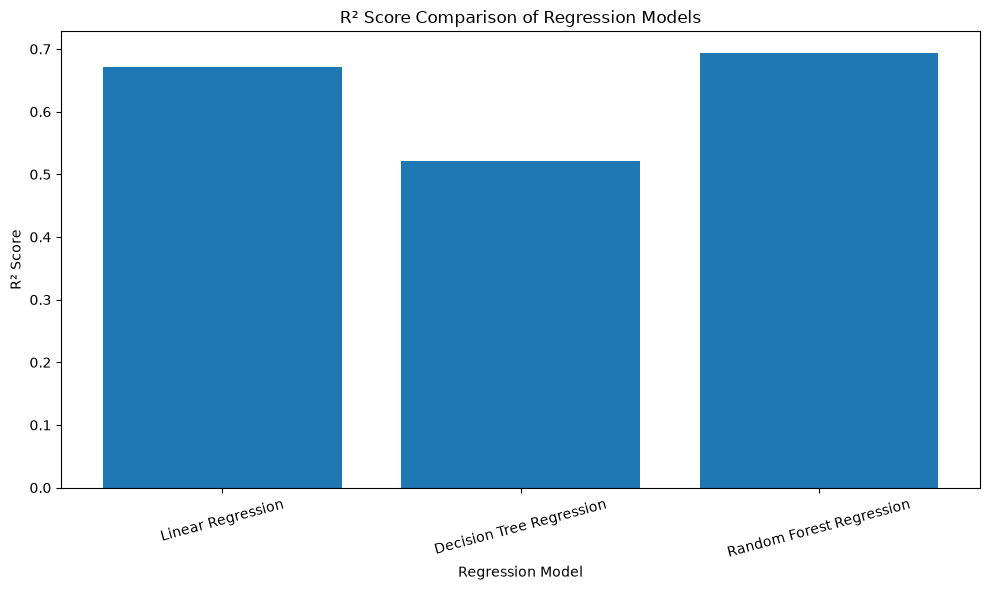

In [32]:
# Model Performance Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

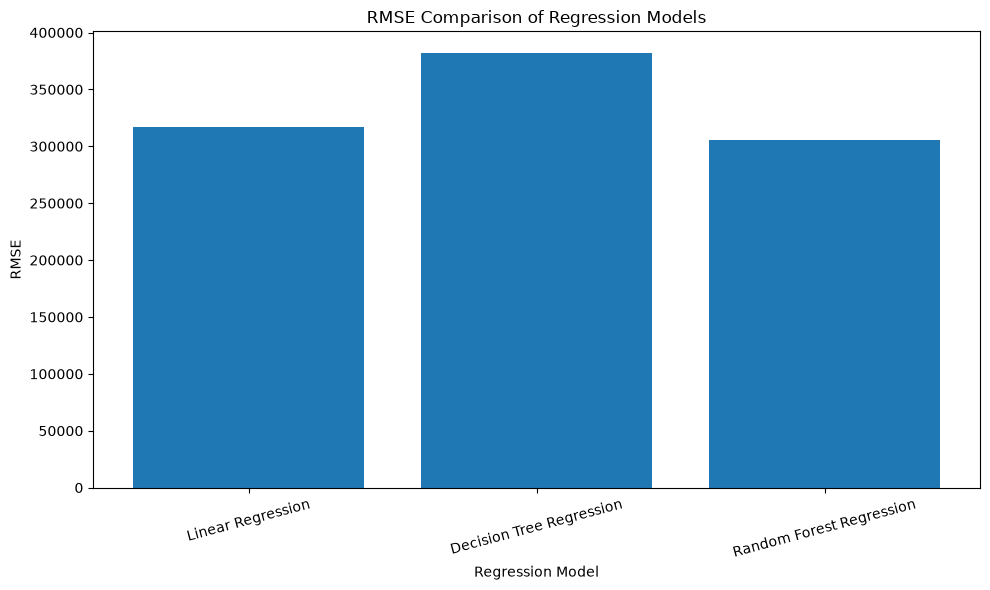

In [33]:
# RMSE Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

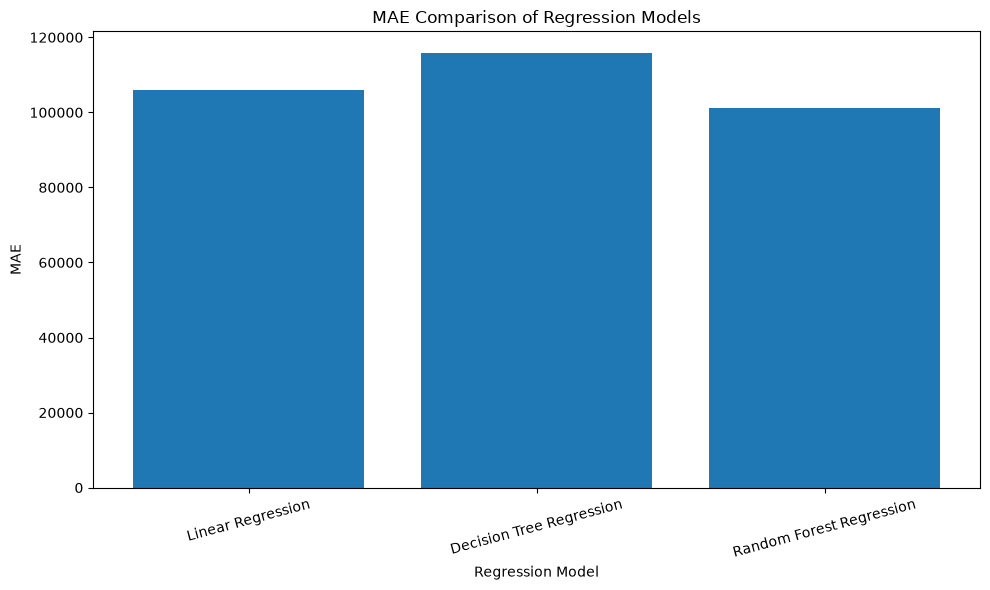

In [34]:
# MAE Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("MAE Comparison of Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

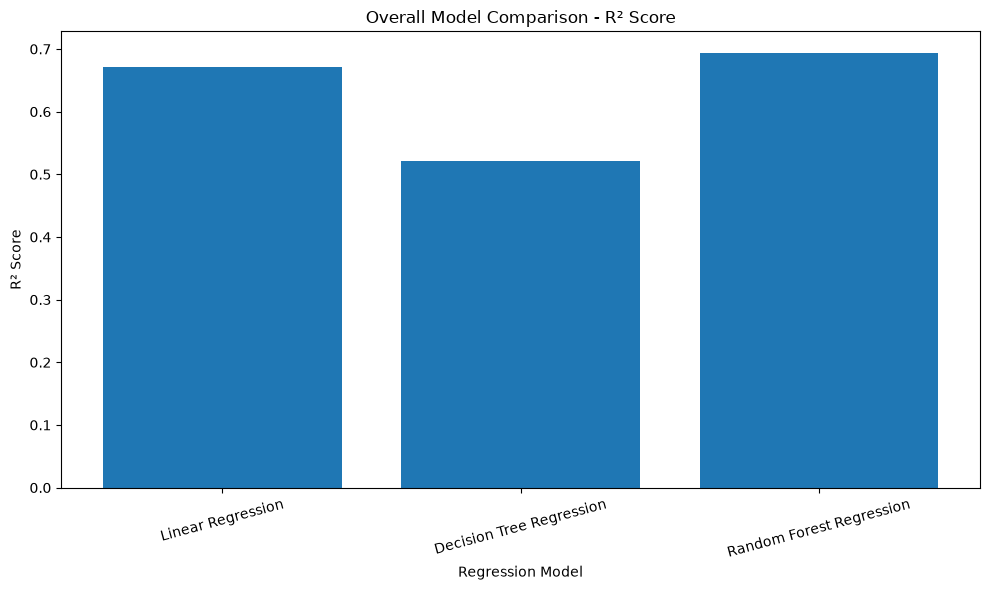

In [35]:
# Overall Model Comparison

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Overall Model Comparison - R² Score")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [36]:
# K-Fold Cross-Validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R² Scores:")
print(cv_scores)

print("\nMean R² Score:", cv_scores.mean())

Cross-Validation R² Scores:
[0.86764632 0.85073113 0.91276556 0.84404522 0.57153778]

Mean R² Score: 0.8093452005884153


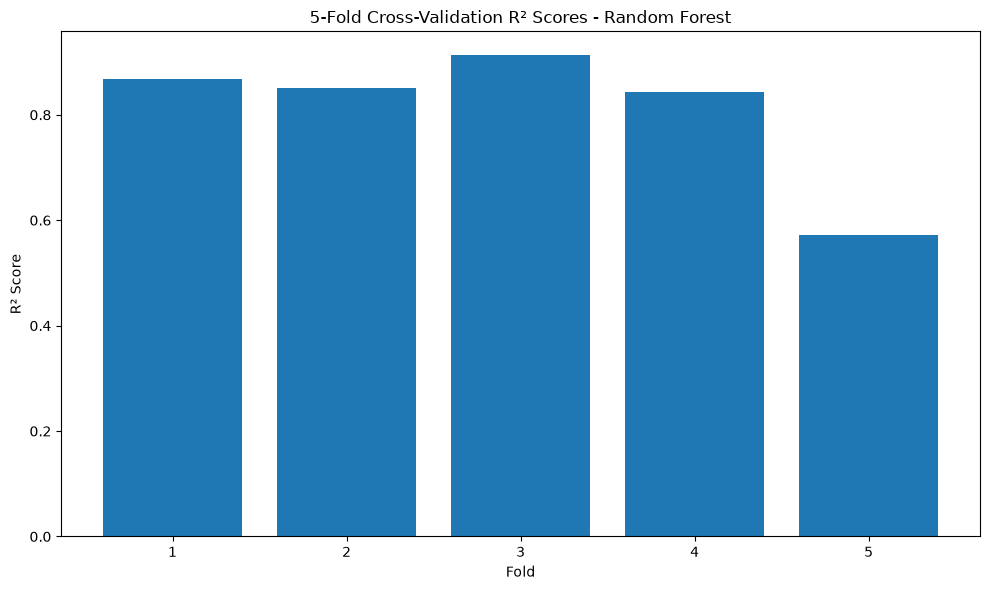

In [37]:
# Cross-Validation R² Score Graph

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, 6),
    cv_scores
)

plt.title("5-Fold Cross-Validation R² Scores - Random Forest")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

In [38]:
# Grid Search for Random Forest

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R² Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation R² Score:
0.7903151426897596


In [ ]:
# Tuned Random Forest Prediction
best_rf_model = grid_search.best_estimator_
tuned_rf_pred = best_rf_model.predict(X_test)
tuned_mae = mean_absolute_error(y_test, tuned_rf_pred)
tuned_mse = mean_squared_error(y_test, tuned_rf_pred)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, tuned_rf_pred)
print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE  :", tuned_mae)
print("MSE  :", tuned_mse)
print("RMSE :", tuned_rmse)
print("R²   :", tuned_r2)

Tuned Random Forest Performance
--------------------------------
MAE  : 100274.74159224819
MSE  : 92395435881.81372
RMSE : 303966.1755554616
R²   : 0.6972331839141983


In [40]:
# Original vs Tuned Random Forest

comparison = pd.DataFrame({
    "Model": ["Original Random Forest", "Tuned Random Forest"],
    "MAE": [results.loc[results["Model"] == "Random Forest Regression", "MAE"].iloc[0], tuned_mae],
    "RMSE": [results.loc[results["Model"] == "Random Forest Regression", "RMSE"].iloc[0], tuned_rmse],
    "R2 Score": [results.loc[results["Model"] == "Random Forest Regression", "R2 Score"].iloc[0], tuned_r2]
})

display(comparison)

,Model,MAE,RMSE,R2 Score
0,Original Random Forest,101082.895292,305835.890885,0.693497
1,Tuned Random Forest,100274.741592,303966.175555,0.697233


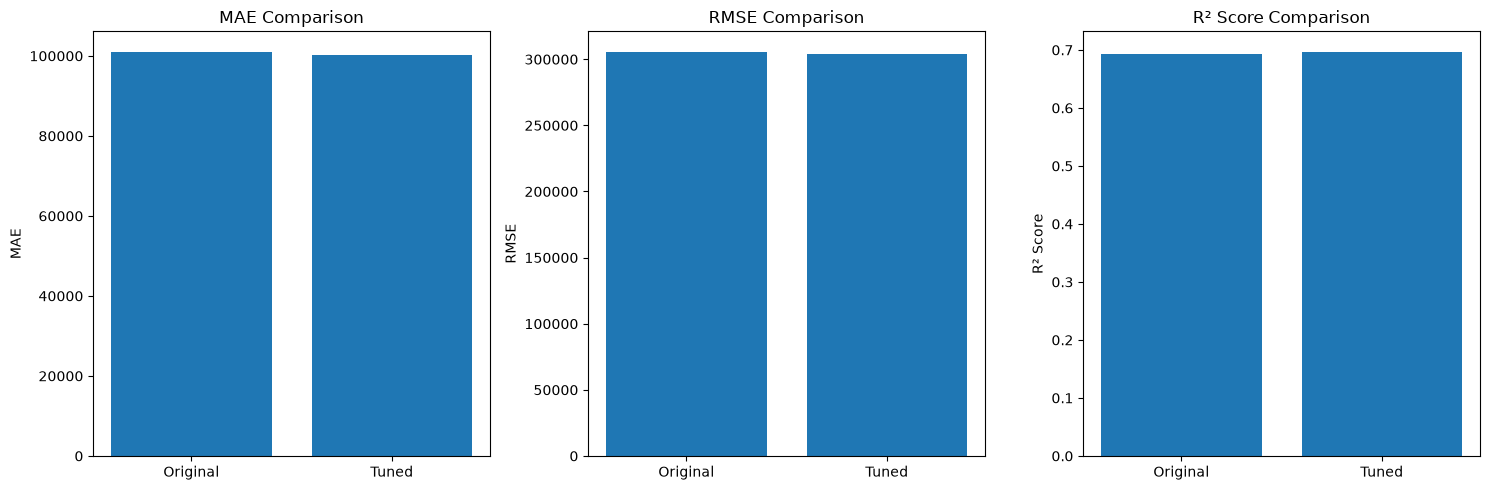

In [41]:
# Original vs Tuned Random Forest - Graph Comparison

metrics = ["MAE", "RMSE", "R2 Score"]

original_values = [
    comparison.loc[0, "MAE"],
    comparison.loc[0, "RMSE"],
    comparison.loc[0, "R2 Score"]
]

tuned_values = [
    comparison.loc[1, "MAE"],
    comparison.loc[1, "RMSE"],
    comparison.loc[1, "R2 Score"]
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE
axes[0].bar(["Original", "Tuned"], [original_values[0], tuned_values[0]])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")

# RMSE
axes[1].bar(["Original", "Tuned"], [original_values[1], tuned_values[1]])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")

# R²
axes[2].bar(["Original", "Tuned"], [original_values[2], tuned_values[2]])
axes[2].set_title("R² Score Comparison")
axes[2].set_ylabel("R² Score")

plt.tight_layout()
plt.show()

In [42]:
#Tuned Random Forest is  best model

In [43]:
# Select Final Best Model

final_model = best_rf_model

print("Final Model Selected: Tuned Random Forest")
print("Final R² Score:", tuned_r2)
print("Final MAE:", tuned_mae)
print("Final RMSE:", tuned_rmse)

Final Model Selected: Tuned Random Forest
Final R² Score: 0.6972331839141983
Final MAE: 100274.74159224819
Final RMSE: 303966.1755554616


In [44]:
#TESTING
# Sample Car Price Prediction

sample_car = X_test.iloc[[0]]

predicted_price = final_model.predict(sample_car)

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 127360.0


In [45]:
# Save Final Model

import joblib

joblib.dump(final_model, "final_model.pkl")

print("Final model saved successfully as final_model.pkl")

Final model saved successfully as final_model.pkl


In [46]:
# Save Scaler

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully as scaler.pkl")

Scaler saved successfully as scaler.pkl


In [47]:
# Final Conclusion

print("FINAL MODEL: Tuned Random Forest Regression")
print("---------------------------------------------")
print("R² Score :", tuned_r2)
print("MAE      :", tuned_mae)
print("RMSE     :", tuned_rmse)

print("\nConclusion:")
print("The Tuned Random Forest Regression model achieved the best overall")
print("performance after hyperparameter tuning using GridSearchCV.")
print("Therefore, it was selected as the final model for Used Car Price Prediction.")

FINAL MODEL: Tuned Random Forest Regression
---------------------------------------------
R² Score : 0.6972331839141983
MAE      : 100274.74159224819
RMSE     : 303966.1755554616

Conclusion:
The Tuned Random Forest Regression model achieved the best overall
performance after hyperparameter tuning using GridSearchCV.
Therefore, it was selected as the final model for Used Car Price Prediction.


In [48]:
# Save Encoded Feature Columns

joblib.dump(
    X_encoded.columns.tolist(),
    "feature_columns.pkl"
)

print("Feature columns saved successfully as feature_columns.pkl")

Feature columns saved successfully as feature_columns.pkl
